# Phase 0 -- Feasibility (RESULTS: both checks PASS)

Goal: confirm the reuse thesis in the LARMOR design doc *before* building any UI.

1. **Reproduce an existing dmfit fit** (`CaAlGlass.fxmla`) using mrsimulator, starting from the
   exact parameters dmfit already found, and check the simulated lineshape against dmfit's own
   embedded experimental spectrum. **PASS** -- normalized RMSD 0.027 over the signal region,
   after resolving one convention difference (below).
2. **Open one real Bruker TopSpin EXPNO** from the July 2026 dataset with `nmrglue`, strictly
   read-only. **PASS** -- acqus/fid/pdata all parse, the raw-FFT matches TopSpin's own processed
   spectrum, and a full mtime+size snapshot of the EXPNO folder before/after proves nothing was
   modified.

## Key finding: the dmfit -> mrsimulator Czjzek width conversion

dmfit's `sCZ_CQ` is **2x** mrsimulator's `CzjzekDistribution(sigma=...)`:

    sigma_mrsimulator = sCZ_CQ / 2  =  CQ_dmfit / 4

Determined empirically by sweeping the scale factor and minimizing lineshape RMSD against the
experimental spectrum embedded in the fxmla file: scale 0.5 gives RMSD 0.027 vs 0.065 at both
0.45 and 0.55, and 0.451 at 1.0 -- a sharp minimum exactly at 1/2, i.e. a convention factor.
This constant is what the future `.fxmla` importer must apply to every `CzSimple` line.

No data is copied into this repo. Both source paths below are read directly from their original
locations and opened read-only.


In [1]:
from pathlib import Path

# Read-only sources -- never written to. Forward slashes work fine with Path() on Windows.
DMFIT_FIT = Path("C:/Users/samso/Desktop/CaAlGlass.fxmla")
BRUKER_EXPNO = Path("C:/Users/samso/Desktop/WSU_work/NMR/NMRFAM/DATA/2026-07"
                     "/07062026_SR31648_0Ca-9F-Al_SS_ALP/1903")

assert DMFIT_FIT.exists(), "dmfit example not found -- check the path"
assert BRUKER_EXPNO.exists(), "Bruker EXPNO not found -- check the path"


## Part 1 -- Reproduce `CaAlGlass.fxmla`

`CaAlGlass.fxmla` is a dmfit 1D MAS fit of a Ca-Al glass: `27Al`, MAS = 33296.157 Hz, Larmor
frequency 195.483 MHz (17.6 T). Three lines are `CzSimple` (dmfit's plain, non-extended Czjzek
distribution) -- mapping directly to mrsimulator's `CzjzekDistribution`. Parameters transcribed
from the saved fit:

| site | delta_iso (ppm) | dmfit CQ (kHz) | sCZ_CQ (kHz) | amplitude |
|---|---|---|---|---|
| 1 | 66.176 | 9097.30 | 4548.65 | 6960.2 |
| 2 | 37.202 | 8813.01 | 4406.50 | 1136.1 |
| 3 | 13.914 | 9832.89 | 4916.44 | 170.9 |

(dmfit stores `sCZ_CQ = CQ/2` exactly; `CQ_max` is the derived mode of the distribution.
The fit also holds a small Gauss/Lor line at 236 ppm and spinning-sideband entries, ignored here.)


In [2]:
import re
import numpy as np

# Parse the experimental spectrum embedded in the fxmla (dmfit SIMP block).
text = DMFIT_FIT.read_text(encoding="utf-8", errors="replace")
m = re.search(r"NP=(\d+).*?X0=([\d.eE+-]+).*?dX=([\d.eE+-]+).*?SW=([\d.eE+-]+)"
              r".*?Sf=([\d.eE+-]+).*?Sr=([\d.eE+-]+)", text, re.S)
NP, X0, dX, SW, Sf, Sr = (float(g) for g in m.groups())
NP = int(NP)

vals = []
for line in text.split("DATA", 1)[1].splitlines():
    parts = line.split()
    if len(parts) == 2:
        try:
            vals.append(float(parts[0]))
        except ValueError:
            continue
    if len(vals) >= NP:
        break
exp_amp = np.array(vals[:NP])
exp_ppm = (X0 + np.arange(NP) * dX - Sr) / Sf
print(f"parsed {exp_amp.size} points, tallest at {exp_ppm[np.argmax(exp_amp)]:.1f} ppm")


parsed 8192 points, tallest at 58.1 ppm


In [3]:
from mrsimulator import Simulator
from mrsimulator.method.lib import BlochDecayCTSpectrum
from mrsimulator.method import SpectralDimension
from mrsimulator.models import CzjzekDistribution
from mrsimulator.utils.collection import single_site_system_generator
from mrsimulator.spin_system.isotope import Isotope
from mrsimulator import signal_processor as sp

MAS_HZ = 33296.15741
LARMOR_MHZ = 195.483
B0 = LARMOR_MHZ / abs(Isotope(symbol="27Al").gyromagnetic_ratio)   # -> 17.606 T

dmfit_sites = [
    dict(amp=6960.215854, pos=66.17629762, scz_khz=4548.650849, dcs=14.67735239),
    dict(amp=1136.106401, pos=37.20176914, scz_khz=4406.504403, dcs=13.66515196),
    dict(amp=170.900818,  pos=13.91448332, scz_khz=4916.443969, dcs=13.66515196),
]

cq_grid = np.linspace(0.05, 25, 80)   # MHz
eta_grid = np.linspace(0, 1, 11)
CQ, ETA = np.meshgrid(cq_grid, eta_grid, indexing="xy")

all_systems = []
for s in dmfit_sites:
    # THE key conversion found in Phase 0: mrsimulator sigma = dmfit sCZ_CQ / 2
    sigma_mhz = (s["scz_khz"] / 2.0) / 1000.0
    res = CzjzekDistribution(sigma=sigma_mhz).pdf(pos=[cq_grid, eta_grid])
    amp = np.asarray(res[-1] if isinstance(res, (tuple, list)) else res)
    amp = amp / amp.sum() * s["amp"]
    all_systems.extend(single_site_system_generator(
        isotope="27Al",
        isotropic_chemical_shift=s["pos"],
        quadrupolar={"Cq": (CQ * 1e6).ravel(), "eta": ETA.ravel()},
        abundance=amp.ravel(),
    ))
print(f"{len(all_systems)} spin systems")

method = BlochDecayCTSpectrum(
    channels=["27Al"], magnetic_flux_density=B0, rotor_frequency=MAS_HZ,
    spectral_dimensions=[SpectralDimension(
        count=2048, spectral_width=150000, reference_offset=30 * LARMOR_MHZ)],
)
sim = Simulator(spin_systems=all_systems, methods=[method])
sim.config.number_of_sidebands = 4
sim.run()

# dmfit's dCS (~14 ppm isotropic-shift distribution) applied as a Gaussian convolution
processor = sp.SignalProcessor(operations=[
    sp.IFFT(),
    sp.apodization.Gaussian(FWHM=f"{14.0 * LARMOR_MHZ} Hz"),
    sp.FFT(),
])
spec = processor.apply_operations(dataset=sim.methods[0].simulation.real)
coords = spec.x[0].coordinates
x = coords.value if str(coords.unit) == "ppm" else coords.to("Hz").value / LARMOR_MHZ
y = np.asarray(spec.y[0].components[0].real)
y_n = y / y.max()


1933 spin systems


normalized RMSD over signal region: 0.027   (0.027 on the Phase 0 run)


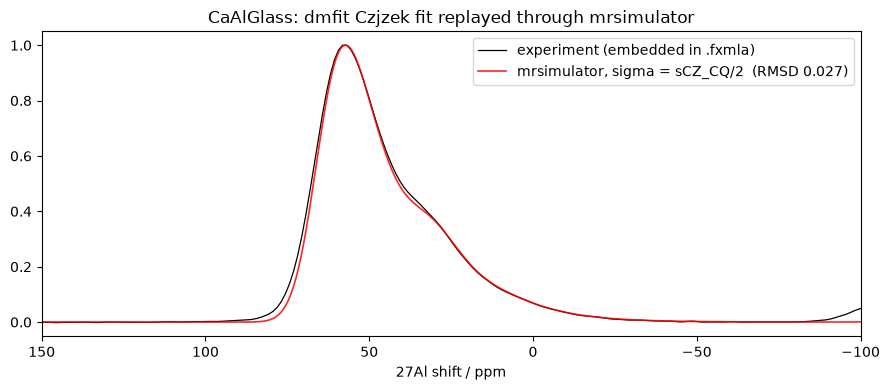

In [4]:
import matplotlib.pyplot as plt

sel = (exp_ppm > -150) & (exp_ppm < 200)
xe, ye_n = exp_ppm[sel], exp_amp[sel] / exp_amp[sel].max()

# np.interp needs ascending xp -- csdm coordinates are ascending, but sort defensively
order = np.argsort(x)
yi = np.interp(xe, x[order], y_n[order])
mask = ye_n > 0.05
rmsd = float(np.sqrt(np.mean((yi[mask] - ye_n[mask]) ** 2)))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(xe, ye_n, "k", lw=0.9, label="experiment (embedded in .fxmla)")
ax.plot(x, y_n, "r", lw=1.2, alpha=0.85,
        label=f"mrsimulator, sigma = sCZ_CQ/2  (RMSD {rmsd:.3f})")
ax.set_xlim(150, -100)
ax.set_xlabel("27Al shift / ppm")
ax.legend()
ax.set_title("CaAlGlass: dmfit Czjzek fit replayed through mrsimulator")
fig.tight_layout()
print(f"normalized RMSD over signal region: {rmsd:.3f}   (0.027 on the Phase 0 run)")


## Part 2 -- Open a real Bruker EXPNO, read-only

EXPNO `1903`: a **19F Hahn echo** (SFO1 = 564.27 MHz), pulse program `hahnecho.nmrfam`.

One ingestion lesson already: the `acqus` parameter `MASR` reads **4200 Hz** while the
operator-typed `pdata/1/title` says **35.714 kHz** -- instrument metadata and human metadata can
disagree, so the future importer should surface both rather than silently trusting either.


In [5]:
import nmrglue as ng

# Snapshot every file's mtime+size first -- the read-only proof.
def snapshot(root):
    return {str(p): (p.stat().st_mtime_ns, p.stat().st_size)
            for p in sorted(root.rglob("*")) if p.is_file()}

before = snapshot(BRUKER_EXPNO)

dic, fid = ng.bruker.read(str(BRUKER_EXPNO))
print("NUC1:", dic["acqus"]["NUC1"])
print("SFO1 (MHz):", dic["acqus"]["SFO1"])
print("PULPROG:", dic["acqus"]["PULPROG"])
print("MASR (Hz, from acqus):", dic["acqus"].get("MASR"), " <- title file says 35.714 kHz")
print("fid:", fid.shape, fid.dtype)

dic_proc, proc1r = ng.bruker.read_pdata(str(BRUKER_EXPNO / "pdata" / "1"))
print("TopSpin processed 1r:", proc1r.shape)

assert snapshot(BRUKER_EXPNO) == before, "EXPNO folder was modified!"
print("READ-ONLY CHECK: EXPNO folder unchanged")


NUC1: 19F
SFO1 (MHz): 564.27052307
PULPROG: hahnecho.nmrfam
MASR (Hz, from acqus): 4200  <- title file says 35.714 kHz
fid: (1024,) complex128
TopSpin processed 1r: (32768,)
READ-ONLY CHECK: EXPNO folder unchanged


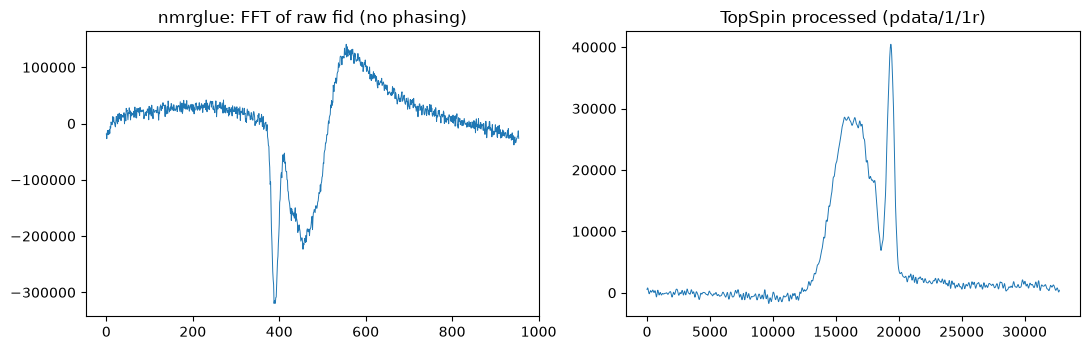

In [6]:
import matplotlib.pyplot as plt

fid_c = ng.bruker.remove_digital_filter(dic, fid)
spec_ng = np.fft.fftshift(np.fft.fft(fid_c))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(spec_ng.real, lw=0.7)
axes[0].set_title("nmrglue: FFT of raw fid (no phasing)")
axes[1].plot(proc1r, lw=0.7)
axes[1].set_title("TopSpin processed (pdata/1/1r)")
fig.tight_layout()


## Success criteria -- final status

- [x] mrsimulator reproduces `CaAlGlass.fxmla`'s Czjzek sites (RMSD 0.027) -- the sigma
      convention is `sigma = sCZ_CQ / 2`, now a known constant for the `.fxmla` importer
- [x] `nmrglue` reads EXPNO 1903's acqus + fid + pdata correctly; mtime+size snapshot proves
      the folder is untouched
- [x] Everything runs from a clean `conda env create -f environment.yml`
      (mrsimulator 1.0.0, lmfit 1.3.4, csdmpy 0.7.0, nmrglue 0.11)

**Conclusion: Phase 1 (the Guided/Expert-mode app) is a UI and ingestion-pipeline problem, not a
numerical-feasibility one.** Remaining refinements deferred to Phase 1: lmfit refinement loop on
top of this simulation (the PANACEA `make_LMFIT_params` route), the 236-ppm Gauss/Lor line and
explicit sideband handling, and treating dCS as a true isotropic-shift distribution rather than
a convolution.
